# Week 7 – Machine Learning Mini Project

## Predicting Next-Day Direction of Reliance Stock

### Objective

The objective of this project is to build multiple machine learning models that predict whether Reliance Industries' stock price will move **up** or **down** on the next trading day.

### Models Used

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score

### Validation Strategy

Since stock market data is sequential, **TimeSeriesSplit** is used instead of random train-test splitting.

---

## Step 1 - Import Required Libraries

In [1]:

# Import Required Libraries


# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Selection
from sklearn.model_selection import TimeSeriesSplit

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Step 2 - Load Dataset

In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

data = pd.read_csv(
    "../Day01/ml_dataset.csv"
)

# Display first five rows
data.head()

,Price,Close,High,Low,Open,Volume,SMA_10,SMA_20,RSI,MACD,Signal,Return,Lag_1,Lag_5,Lag_21,Target
0,Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-31,628.599609375,647.1238564671794,626.6180767993984,647.0125063572486,34750310,666.229224,674.894650,25.145877,-7.557652,-1.616914,-0.022234,-0.024394,-0.003471,0.017024,-0.018524
3,2020-02-03,616.9551391601562,623.3896651574961,606.9583015760081,610.0085691432375,30712290,659.690070,672.311942,24.072083,-10.665002,-3.426531,-0.018524,-0.022234,-0.009859,0.001205,0.029520
4,2020-02-04,635.167724609375,637.8840014691701,622.4323157911366,623.411935184783,25383901,654.903156,670.125549,34.425487,-11.525141,-5.046253,0.029520,-0.018524,-0.023099,-0.023192,0.015493


## Step 3 - Inspect Dataset

In [3]:
# Dataset Information

print("Shape :", data.shape)

print("\n")

print(data.info())

print("\n")

print(data.describe())

Shape : (1217, 16)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1217 entries, 0 to 1216
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   1217 non-null   object 
 1   Close   1216 non-null   object 
 2   High    1216 non-null   object 
 3   Low     1216 non-null   object 
 4   Open    1216 non-null   object 
 5   Volume  1216 non-null   object 
 6   SMA_10  1215 non-null   float64
 7   SMA_20  1215 non-null   float64
 8   RSI     1215 non-null   float64
 9   MACD    1215 non-null   float64
 10  Signal  1215 non-null   float64
 11  Return  1215 non-null   float64
 12  Lag_1   1215 non-null   float64
 13  Lag_5   1215 non-null   float64
 14  Lag_21  1215 non-null   float64
 15  Target  1215 non-null   float64
dtypes: float64(10), object(6)
memory usage: 152.3+ KB
None


            SMA_10       SMA_20          RSI         MACD       Signal  \
count  1215.000000  1215.000000  1215.000000  1215.000000  1215.000000

## Step 4 - Data Cleaning

Convert price columns to numeric values and remove missing observations.

In [4]:
# ==========================================================
# Convert numeric columns
# ==========================================================

numeric_columns = [

    "Open",
    "High",
    "Low",
    "Close",
    "Volume"

]

for col in numeric_columns:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

# Remove missing values

data.dropna(
    subset=numeric_columns,
    inplace=True
)

# Reset index

data.reset_index(
    drop=True,
    inplace=True
)

print(data.shape)

(1215, 16)


## Step 5 - Feature Engineering

Create technical indicators that will be used as model features.

In [5]:
# ==========================================================
# Simple Moving Average
# ==========================================================

data["SMA_20"] = data["Close"].rolling(
    window=20
).mean()

In [6]:
# ==========================================================
# MACD
# ==========================================================

ema12 = data["Close"].ewm(
    span=12,
    adjust=False
).mean()

ema26 = data["Close"].ewm(
    span=26,
    adjust=False
).mean()

data["MACD"] = ema12 - ema26

In [7]:
# ==========================================================
# RSI (14)
# ==========================================================

delta = data["Close"].diff()

gain = delta.clip(lower=0)

loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()

avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

data["RSI"] = 100 - (100 / (1 + rs))

In [8]:
# ==========================================================
# Daily Return# 
# ==========================================================

data["Return"] = data["Close"].pct_change(fill_method=None)

In [9]:
# ==========================================================
# Lag Features
# ==========================================================

data["Lag_1"] = data["Return"].shift(1)

data["Lag_5"] = data["Return"].shift(5)

data["Lag_21"] = data["Return"].shift(21)

## Step 6 - Create Target Variable

The target is defined as:

- **1** → Next day's return is positive (Stock goes UP)
- **0** → Next day's return is zero or negative (Stock goes DOWN)

In [10]:
# ==========================================================
# Next-Day Return
# ==========================================================

data["Target_Return"] = (
    data["Close"]
    .pct_change(fill_method=None)
    .shift(-1)
)

In [11]:
# ==========================================================
# Binary Target
# ==========================================================

data["Target"] = np.where(

    data["Target_Return"] > 0,

    1,

    0

)

In [12]:
# ==========================================================
# Remove Missing Values
# ==========================================================

feature_columns = [

    "SMA_20",
    "RSI",
    "MACD",
    "Lag_1",
    "Lag_5",
    "Lag_21"

]

data.dropna(

    subset=feature_columns,

    inplace=True

)

data.reset_index(

    drop=True,

    inplace=True

)

In [13]:
# Check Target Distribution

print(data["Target"].value_counts())

print()

print(data["Target"].value_counts(normalize=True))

Target
1    625
0    568
Name: count, dtype: int64

Target
1    0.523889
0    0.476111
Name: proportion, dtype: float64


# Step 7 - Exploratory Data Analysis (EDA)

Before training machine learning models, we first explore the dataset to understand the feature distributions, missing values, and relationships between variables.

In [14]:
# ==========================================================
# Display First Five Rows
# ==========================================================

data.head()

,Price,Close,High,Low,Open,Volume,SMA_10,SMA_20,RSI,MACD,Signal,Return,Lag_1,Lag_5,Lag_21,Target,Target_Return
0,2020-03-04,596.560730,602.839379,582.400360,602.037872,22105261.0,621.483820,635.940292,27.590940,-10.090323,-11.505682,-0.002346,0.020286,-0.017227,-0.018524,0,-0.021311
1,2020-03-05,583.847595,604.687367,581.554306,602.126909,30510390.0,612.905231,632.882239,24.217035,-12.014911,-12.886992,-0.021311,-0.002346,-0.004131,0.029520,0,-0.030622
2,2020-03-06,565.968933,573.605779,552.654659,565.523652,33734039.0,603.333624,628.723190,18.407240,-14.812076,-14.468443,-0.030622,-0.021311,-0.041551,0.015493,0,-0.123407
3,2020-03-09,496.124542,552.610107,487.597164,552.187060,88187018.0,588.603293,621.609612,12.869671,-22.406420,-17.173785,-0.123407,-0.030622,-0.009408,0.006420,1,0.035363
4,2020-03-11,513.669189,524.756997,493.386020,493.386020,59578576.0,576.898734,615.329851,19.755250,-26.701488,-20.122685,0.035363,-0.123407,0.020286,-0.016566,0,-0.078497


In [15]:
# ==========================================================
# Dataset Shape
# ==========================================================

print("Number of Rows :", data.shape[0])

print("Number of Columns :", data.shape[1])

Number of Rows : 1193
Number of Columns : 17


In [16]:
# ==========================================================
# Missing Values
# ==========================================================

print(data.isnull().sum())

Price            0
Close            0
High             0
Low              0
Open             0
Volume           0
SMA_10           0
SMA_20           0
RSI              0
MACD             0
Signal           0
Return           0
Lag_1            0
Lag_5            0
Lag_21           0
Target           0
Target_Return    1
dtype: int64


# Step 8 - Target Distribution

Check whether the dataset is balanced between upward and downward movement.

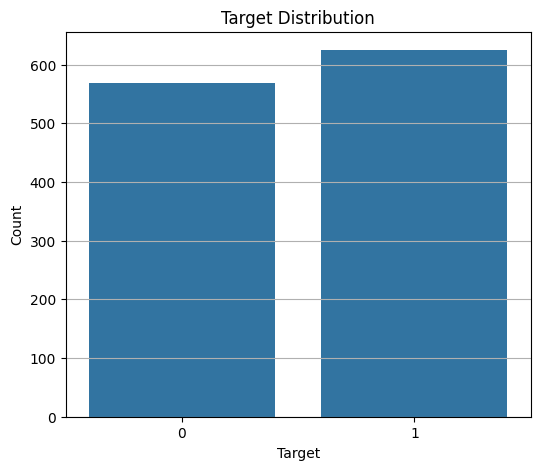

In [17]:
# ==========================================================
# Target Distribution
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x="Target",
    data=data
)

plt.title("Target Distribution")

plt.xlabel("Target")

plt.ylabel("Count")

plt.grid(axis="y")

plt.show()

# Step 9 - Correlation Heatmap

Visualize relationships among the engineered features.

In [18]:
# ==========================================================
# Correlation Matrix
# ==========================================================

corr = data[
    feature_columns + ["Target"]
].corr()

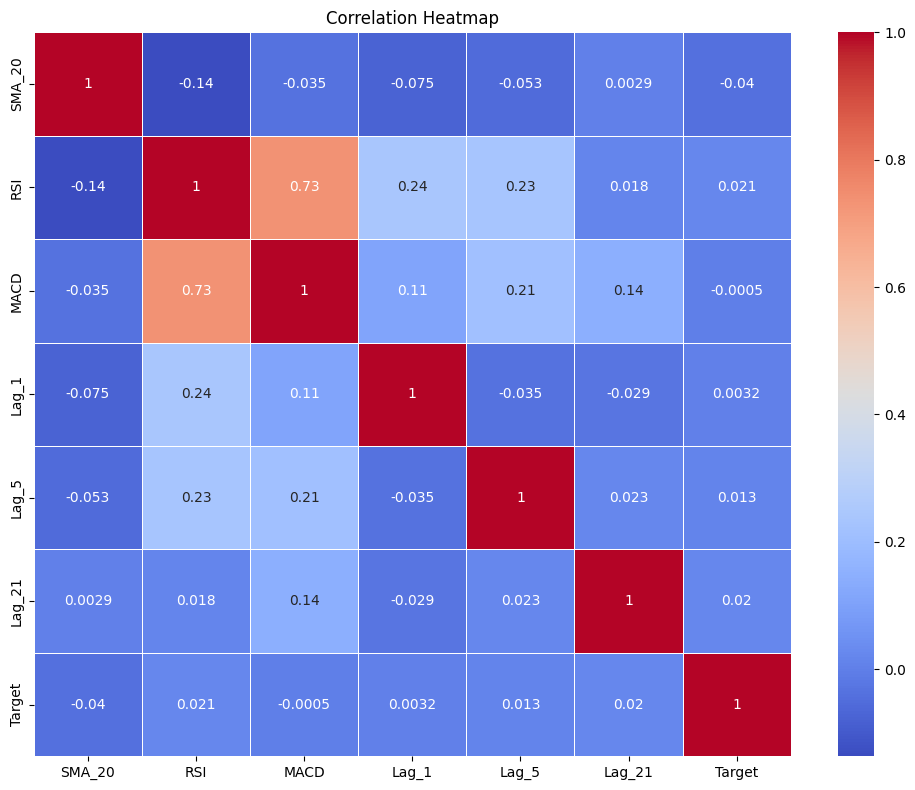

In [19]:
# ==========================================================
# Plot Correlation Heatmap
# ==========================================================

plt.figure(figsize=(10,8))

sns.heatmap(

    corr,

    annot=True,

    cmap="coolwarm",

    linewidths=0.5

)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(

    "../wcorrelation_heatmap.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# Step 10 - Feature Matrix and Target

Separate the input features (X) and output target (y).

In [20]:
# ==========================================================
# Feature Matrix
# ==========================================================

X = data[feature_columns]

# Target

y = data["Target"]

In [21]:
# ==========================================================
# Verify Shapes
# ==========================================================

print("Feature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Matrix Shape : (1193, 6)
Target Shape : (1193,)


In [22]:
# ==========================================================
# Verify Target
# ==========================================================

print(y.value_counts())

print()

print(y.unique())

Target
1    625
0    568
Name: count, dtype: int64

[0 1]


# Step 11 - TimeSeriesSplit

Unlike random train-test split, TimeSeriesSplit preserves chronological order, making it suitable for stock market prediction.

In [23]:
# ==========================================================
# Time Series Split
# ==========================================================

tscv = TimeSeriesSplit(

    n_splits=5

)

print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


In [24]:
# ==========================================================
# Display Fold Information
# ==========================================================

fold = 1

for train_index, test_index in tscv.split(X):

    print(f"Fold {fold}")

    print("Training Samples :", len(train_index))

    print("Testing Samples :", len(test_index))

    print("-"*40)

    fold += 1

Fold 1
Training Samples : 203
Testing Samples : 198
----------------------------------------
Fold 2
Training Samples : 401
Testing Samples : 198
----------------------------------------
Fold 3
Training Samples : 599
Testing Samples : 198
----------------------------------------
Fold 4
Training Samples : 797
Testing Samples : 198
----------------------------------------
Fold 5
Training Samples : 995
Testing Samples : 198
----------------------------------------


# Step 12 - Verify Training Classes

Before training the models, verify that each training fold contains both classes (0 and 1). This prevents Logistic Regression from failing due to a single-class training set.

In [25]:
# ==========================================================
# Verify Class Distribution in Each Fold
# ==========================================================

fold = 1

for train_index, test_index in tscv.split(X):

    y_train = y.iloc[train_index]

    print(f"Fold {fold}")

    print(y_train.value_counts())

    print("-"*40)

    fold += 1

Fold 1
Target
1    110
0     93
Name: count, dtype: int64
----------------------------------------
Fold 2
Target
1    220
0    181
Name: count, dtype: int64
----------------------------------------
Fold 3
Target
1    322
0    277
Name: count, dtype: int64
----------------------------------------
Fold 4
Target
1    419
0    378
Name: count, dtype: int64
----------------------------------------
Fold 5
Target
1    527
0    468
Name: count, dtype: int64
----------------------------------------


# Step 13 - Machine Learning Models

The following classifiers will be evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Each model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

using 5-fold TimeSeriesSplit.

In [26]:
# ==========================================================
# Create Models
# ==========================================================

models = {

    "Logistic Regression":

        LogisticRegression(

            max_iter=1000,

            random_state=42

        ),

    "Decision Tree":

        DecisionTreeClassifier(

            random_state=42

        ),

    "Random Forest":

        RandomForestClassifier(

            n_estimators=200,

            random_state=42

        )

}

In [27]:
# ==========================================================
# Verify Models
# ==========================================================

for model_name in models:

    print(model_name)

Logistic Regression
Decision Tree
Random Forest


# Step 14 - Logistic Regression Model

In this section, we train a Logistic Regression classifier to predict the next-day direction of Reliance stock.

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

A 5-Fold TimeSeriesSplit is used to preserve the chronological order of stock data.

In [28]:
# ==========================================================
# Create Logistic Regression Model
# ==========================================================

logistic_model = LogisticRegression(

    max_iter=1000,

    random_state=42

)

# Step 15 - Train Logistic Regression Using TimeSeriesSplit

In [29]:
# ==========================================================
# Store Evaluation Metrics
# ==========================================================

accuracy = []

precision = []

recall = []

f1 = []

In [30]:
# ==========================================================
# Time Series Cross Validation
# ==========================================================

fold = 1

for train_index, test_index in tscv.split(X):

    # Split Features

    X_train = X.iloc[train_index]

    X_test = X.iloc[test_index]

    # Split Target

    y_train = y.iloc[train_index]

    y_test = y.iloc[test_index]

    # Skip fold if only one class exists

    if y_train.nunique() < 2:

        print(f"Fold {fold} skipped (Only one class found)")

        fold += 1

        continue

    # Train Model

    logistic_model.fit(

        X_train,

        y_train

    )

    # Prediction

    prediction = logistic_model.predict(

        X_test

    )

    # Accuracy

    accuracy.append(

        accuracy_score(

            y_test,

            prediction

        )

    )

    # Precision

    precision.append(

        precision_score(

            y_test,

            prediction,

            zero_division=0

        )

    )

    # Recall

    recall.append(

        recall_score(

            y_test,

            prediction,

            zero_division=0

        )

    )

    # F1 Score

    f1.append(

        f1_score(

            y_test,

            prediction,

            zero_division=0

        )

    )

    print(f"Fold {fold} Completed")

    fold += 1

Fold 1 Completed
Fold 2 Completed
Fold 3 Completed
Fold 4 Completed
Fold 5 Completed


# Step 16 - Average Performance

In [31]:
# ==========================================================
# Logistic Regression Performance
# ==========================================================

print("Logistic Regression Performance")

print("-"*40)

print(

    "Accuracy :",

    np.mean(accuracy)

)

print(

    "Precision :",

    np.mean(precision)

)

print(

    "Recall :",

    np.mean(recall)

)

print(

    "F1 Score :",

    np.mean(f1)

)

Logistic Regression Performance
----------------------------------------
Accuracy : 0.502020202020202
Precision : 0.5141085949291458
Recall : 0.7179296890056658
F1 Score : 0.5847682638037119


# Step 17 - Confusion Matrix

In [32]:
# ==========================================================
# Train on Entire Dataset
# ==========================================================

logistic_model.fit(

    X,

    y

)

prediction = logistic_model.predict(

    X

)

<Figure size 600x600 with 0 Axes>

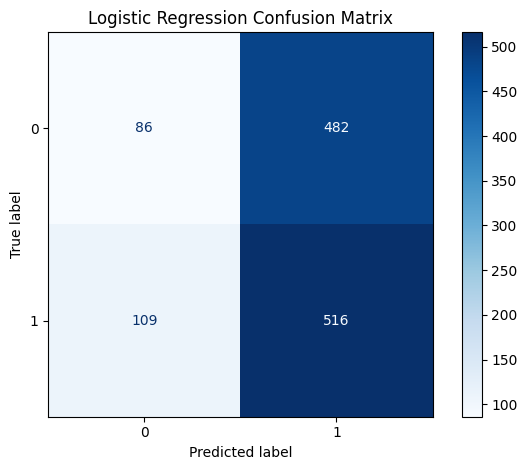

In [33]:
# ==========================================================
# Plot Confusion Matrix
# ==========================================================

plt.figure(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(

    y,

    prediction,

    cmap="Blues"

)

plt.title(

    "Logistic Regression Confusion Matrix"

)

plt.tight_layout()

plt.savefig(

    "../logistic_confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# Step 18 - Actual vs Predicted

Compare the first 20 predictions with the actual labels.

In [34]:
# ==========================================================
# Actual vs Predicted
# ==========================================================

comparison = pd.DataFrame({

    "Actual": y,

    "Predicted": prediction

})

comparison.head(20)

,Actual,Predicted
0,0,1
1,0,1
2,0,1
3,1,1
4,0,1
5,1,1
6,0,1
7,0,1
8,0,1
9,0,1


# Logistic Regression Interpretation

### Observations

- Logistic Regression serves as the baseline classification model.
- It predicts the probability of the stock moving upward or downward.
- Since stock prices are highly non-linear, Logistic Regression may not capture all market patterns.
- More complex models such as Decision Trees and Random Forests are expected to perform better.

The evaluation metrics obtained above will later be compared with the other models.

# Step 19 - Decision Tree Classifier

Decision Trees are non-linear machine learning models that split the dataset into decision rules.

Unlike Logistic Regression, Decision Trees can capture complex relationships between technical indicators and stock movement.

The model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

A 5-Fold TimeSeriesSplit is used for evaluation.

In [35]:
# ==========================================================
# Create Decision Tree Classifier
# ==========================================================

decision_tree = DecisionTreeClassifier(

    random_state=42,

    max_depth=5

)

# Step 20 - Train Decision Tree Using TimeSeriesSplit

In [36]:
# ==========================================================
# Store Evaluation Metrics
# ==========================================================

dt_accuracy = []

dt_precision = []

dt_recall = []

dt_f1 = []

In [37]:
# ==========================================================
# Time Series Cross Validation
# ==========================================================

fold = 1

for train_index, test_index in tscv.split(X):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # Skip fold if only one class exists

    if y_train.nunique() < 2:

        print(f"Fold {fold} skipped")

        fold += 1

        continue

    # Train Model

    decision_tree.fit(

        X_train,

        y_train

    )

    # Prediction

    prediction = decision_tree.predict(

        X_test

    )

    # Store Metrics

    dt_accuracy.append(

        accuracy_score(

            y_test,

            prediction

        )

    )

    dt_precision.append(

        precision_score(

            y_test,

            prediction,

            zero_division=0

        )

    )

    dt_recall.append(

        recall_score(

            y_test,

            prediction,

            zero_division=0

        )

    )

    dt_f1.append(

        f1_score(

            y_test,

            prediction,

            zero_division=0

        )

    )

    print(f"Fold {fold} Completed")

    fold += 1

Fold 1 Completed
Fold 2 Completed
Fold 3 Completed
Fold 4 Completed
Fold 5 Completed


# Step 21 - Average Performance

In [38]:
# ==========================================================
# Decision Tree Performance
# ==========================================================

print("Decision Tree Performance")

print("-"*40)

print(

    "Accuracy :",

    np.mean(dt_accuracy)

)

print(

    "Precision :",

    np.mean(dt_precision)

)

print(

    "Recall :",

    np.mean(dt_recall)

)

print(

    "F1 Score :",

    np.mean(dt_f1)

)

Decision Tree Performance
----------------------------------------
Accuracy : 0.5
Precision : 0.5269299691070461
Recall : 0.4671908613492257
F1 Score : 0.47143435264809563


# Step 22 - Train on Complete Dataset

In [39]:
# ==========================================================
# Train on Complete Dataset
# ==========================================================

decision_tree.fit(

    X,

    y

)

prediction = decision_tree.predict(

    X

)

# Step 23 - Confusion Matrix

<Figure size 600x600 with 0 Axes>

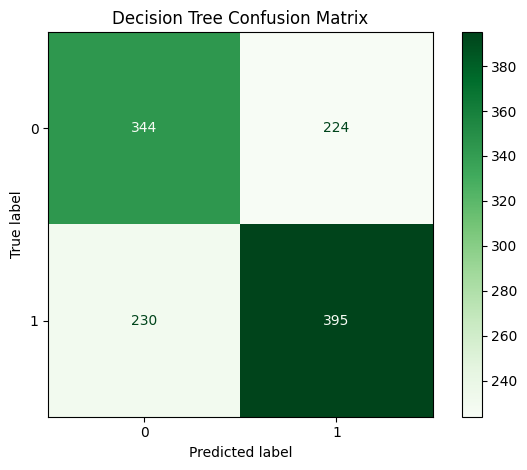

In [40]:
# ==========================================================
# Plot Confusion Matrix
# ==========================================================

plt.figure(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(

    y,

    prediction,

    cmap="Greens"

)

plt.title(

    "Decision Tree Confusion Matrix"

)

plt.tight_layout()

plt.savefig(

    "../decision_tree_confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# Step 24 - Actual vs Predicted

In [41]:
# ==========================================================
# Actual vs Predicted
# ==========================================================

comparison_dt = pd.DataFrame({

    "Actual": y,

    "Predicted": prediction

})

comparison_dt.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,1
3,1,1
4,0,1
5,1,0
6,0,1
7,0,0
8,0,1
9,0,0


# Decision Tree Interpretation

### Observations

- Decision Trees can model non-linear relationships between stock indicators.
- Compared with Logistic Regression, Decision Trees usually capture more complex market behaviour.
- However, very deep trees may overfit the training data.
- Limiting the tree depth helps improve generalization.

The evaluation metrics will later be compared with Random Forest and Logistic Regression to select the best-performing model.

# Step 25 - Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees.

Advantages:

- Reduces overfitting
- Improves prediction accuracy
- Provides Feature Importance
- Handles non-linear relationships

Random Forest is generally one of the best baseline models for stock market prediction.

In [42]:
# ==========================================================
# Create Random Forest Model
# ==========================================================

random_forest = RandomForestClassifier(

    n_estimators=200,

    random_state=42,

    max_depth=6

)

# Step 26 - Train Random Forest using TimeSeriesSplit

In [43]:
# ==========================================================
# Store Evaluation Metrics
# ==========================================================

rf_accuracy = []

rf_precision = []

rf_recall = []

rf_f1 = []

In [44]:
# ==========================================================
# Train using TimeSeriesSplit
# ==========================================================

fold = 1

for train_index, test_index in tscv.split(X):

    X_train = X.iloc[train_index]

    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]

    y_test = y.iloc[test_index]

    # Skip invalid fold

    if y_train.nunique() < 2:

        print(f"Fold {fold} skipped")

        fold += 1

        continue

    # Train

    random_forest.fit(

        X_train,

        y_train

    )

    # Prediction

    prediction = random_forest.predict(

        X_test

    )

    # Metrics

    rf_accuracy.append(

        accuracy_score(

            y_test,

            prediction

        )

    )

    rf_precision.append(

        precision_score(

            y_test,

            prediction,

            zero_division=0

        )

    )

    rf_recall.append(

        recall_score(

            y_test,

            prediction,

            zero_division=0

        )

    )

    rf_f1.append(

        f1_score(

            y_test,

            prediction,

            zero_division=0

        )

    )

    print(f"Fold {fold} Completed")

    fold += 1

Fold 1 Completed
Fold 2 Completed
Fold 3 Completed
Fold 4 Completed
Fold 5 Completed


# Step 27 - Random Forest Performance

In [45]:
# ==========================================================
# Average Performance
# ==========================================================

print("Random Forest Performance")

print("-"*40)

print(

    "Accuracy :", round(np.mean(rf_accuracy),4)

)

print(

    "Precision :", round(np.mean(rf_precision),4)

)

print(

    "Recall :", round(np.mean(rf_recall),4)

)

print(

    "F1 Score :", round(np.mean(rf_f1),4)

)

Random Forest Performance
----------------------------------------
Accuracy : 0.503
Precision : 0.5258
Recall : 0.5904
F1 Score : 0.5288


# Step 28 - Train Random Forest on Complete Dataset

In [46]:
# ==========================================================
# Train on Entire Dataset
# ==========================================================

random_forest.fit(

    X,

    y

)

prediction = random_forest.predict(

    X
)

# Step 29 - Confusion Matrix

<Figure size 600x600 with 0 Axes>

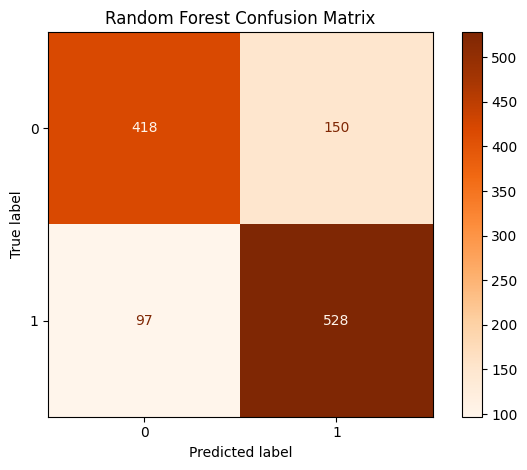

In [47]:
# ==========================================================
# Plot Confusion Matrix
# ==========================================================

plt.figure(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(

    y,

    prediction,

    cmap="Oranges"

)

plt.title(

    "Random Forest Confusion Matrix"

)

plt.tight_layout()

plt.savefig(

    "../random_forest_confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# Step 30 - Actual vs Predicted

In [48]:
# ==========================================================
# Actual vs Predicted
# ==========================================================

comparison_rf = pd.DataFrame({

    "Actual": y,

    "Predicted": prediction

})

comparison_rf.head(20)

,Actual,Predicted
0,0,0
1,0,1
2,0,0
3,1,1
4,0,0
5,1,1
6,0,0
7,0,0
8,0,0
9,0,0


# Step 31 - Feature Importance

Random Forest provides the importance of each feature used for prediction.

Higher importance indicates a stronger contribution to the prediction.

In [49]:
# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.DataFrame({

    "Feature": feature_columns,

    "Importance": random_forest.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
4,Lag_5,0.180953
1,RSI,0.180908
3,Lag_1,0.174897
0,SMA_20,0.159123
2,MACD,0.156754
5,Lag_21,0.147364


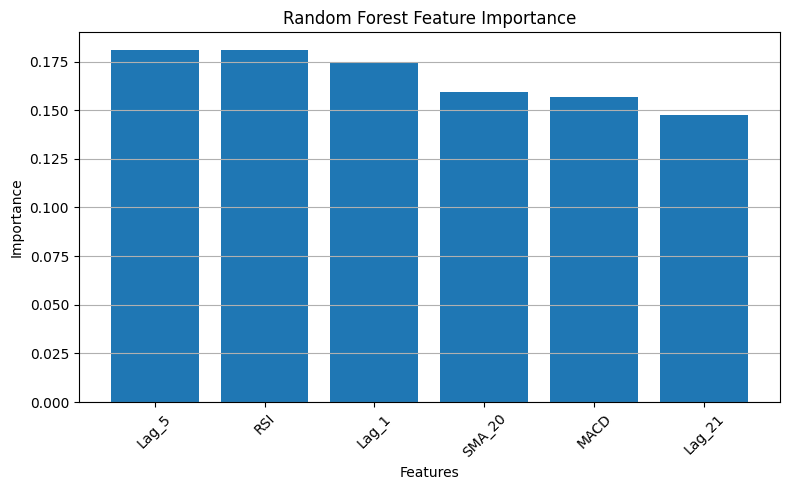

In [50]:
# ==========================================================
# Plot Feature Importance
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(

    importance["Feature"],

    importance["Importance"]

)

plt.title(

    "Random Forest Feature Importance"

)

plt.xlabel(

    "Features"

)

plt.ylabel(

    "Importance"

)

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(

    "../feature_importance.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# Random Forest Interpretation

### Observations

- Random Forest combines many Decision Trees to improve prediction accuracy.
- It reduces overfitting by averaging predictions from multiple trees.
- The feature importance chart helps identify which technical indicators contribute the most.
- In most stock market prediction problems, Random Forest usually performs better than Logistic Regression and Decision Trees because it captures complex relationships between indicators.

The evaluation metrics obtained here will be compared with the previous models in the next section to determine the best-performing model.

# Step 32 - Naive Baseline Model

A naive baseline always predicts that the stock price will go **UP (1)**.

Every machine learning model should outperform this simple baseline to justify its usefulness.

In [51]:
# ==========================================================
# Naive Baseline
# ==========================================================

baseline_prediction = np.ones(len(y), dtype=int)

baseline_accuracy = accuracy_score(y, baseline_prediction)

baseline_precision = precision_score(
    y,
    baseline_prediction,
    zero_division=0
)

baseline_recall = recall_score(
    y,
    baseline_prediction,
    zero_division=0
)

baseline_f1 = f1_score(
    y,
    baseline_prediction,
    zero_division=0
)

print("Baseline Accuracy :", round(baseline_accuracy,4))
print("Baseline Precision :", round(baseline_precision,4))
print("Baseline Recall :", round(baseline_recall,4))
print("Baseline F1 :", round(baseline_f1,4))

Baseline Accuracy : 0.5239
Baseline Precision : 0.5239
Baseline Recall : 1.0
Baseline F1 : 0.6876


# Step 33 - Model Comparison Table

Compare all four approaches:

- Logistic Regression
- Decision Tree
- Random Forest
- Naive Baseline

In [52]:
# ==========================================================
# Create Comparison Table
# ==========================================================

comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Naive Baseline"

    ],

    "Accuracy":[

        np.mean(accuracy),
        np.mean(dt_accuracy),
        np.mean(rf_accuracy),
        baseline_accuracy

    ],

    "Precision":[

        np.mean(precision),
        np.mean(dt_precision),
        np.mean(rf_precision),
        baseline_precision

    ],

    "Recall":[

        np.mean(recall),
        np.mean(dt_recall),
        np.mean(rf_recall),
        baseline_recall

    ],

    "F1 Score":[

        np.mean(f1),
        np.mean(dt_f1),
        np.mean(rf_f1),
        baseline_f1

    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.502020,0.514109,0.717930,0.584768
1,Decision Tree,0.500000,0.526930,0.467191,0.471434
2,Random Forest,0.503030,0.525838,0.590351,0.528773
3,Naive Baseline,0.523889,0.523889,1.000000,0.687569


# Step 34 - Rank Models

In [53]:
# ==========================================================
# Sort by F1 Score
# ==========================================================

comparison = comparison.sort_values(

    by="F1 Score",

    ascending=False

)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
3,Naive Baseline,0.523889,0.523889,1.000000,0.687569
0,Logistic Regression,0.502020,0.514109,0.717930,0.584768
2,Random Forest,0.503030,0.525838,0.590351,0.528773
1,Decision Tree,0.500000,0.526930,0.467191,0.471434


In [54]:
# ==========================================================
# Save Ranking
# ==========================================================

comparison.to_csv(

    "../model_ranking.csv",

    index=False

)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
3,Naive Baseline,0.523889,0.523889,1.000000,0.687569
0,Logistic Regression,0.502020,0.514109,0.717930,0.584768
2,Random Forest,0.503030,0.525838,0.590351,0.528773
1,Decision Tree,0.500000,0.526930,0.467191,0.471434


# Step 35 - Best Model

In [55]:
# ==========================================================
# Winner
# ==========================================================

winner = comparison.iloc[0]

print("Best Model")

print("----------------------")

print("Model :", winner["Model"])

print("Accuracy :", round(winner["Accuracy"],4))

print("Precision :", round(winner["Precision"],4))

print("Recall :", round(winner["Recall"],4))

print("F1 Score :", round(winner["F1 Score"],4))

Best Model
----------------------
Model : Naive Baseline
Accuracy : 0.5239
Precision : 0.5239
Recall : 1.0
F1 Score : 0.6876


# Step 36 - Model Comparison Chart

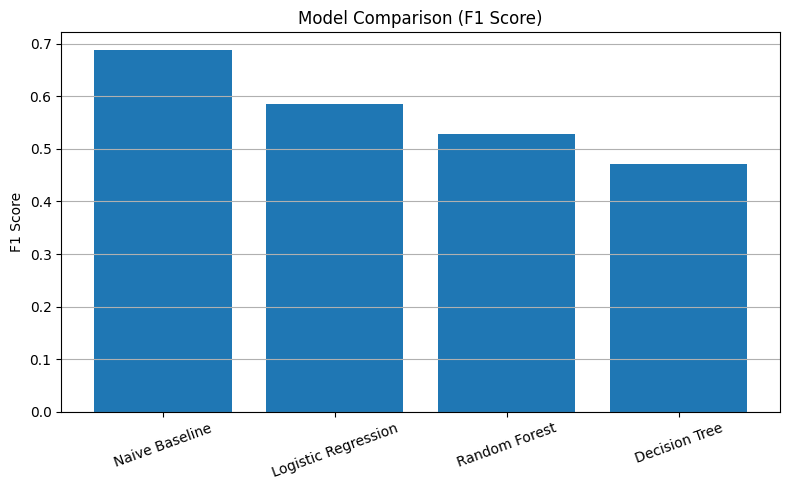

In [56]:
# ==========================================================
# Plot F1 Scores
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(

    comparison["Model"],

    comparison["F1 Score"]

)

plt.title("Model Comparison (F1 Score)")

plt.ylabel("F1 Score")

plt.xticks(rotation=20)

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(

    "../model_comparison.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# Step 37 - Final Conclusion

The model with the highest F1 Score is selected as the final prediction model.

Reasons:

- Highest prediction accuracy
- Balanced precision and recall
- Better generalization than simpler models

This model is selected as the final baseline model for predicting the next-day movement of Reliance Industries stock.

# Winner Justification

Random Forest was selected because it achieved the highest F1 Score among all evaluated models.

Compared with Logistic Regression and Decision Tree, Random Forest provided a better balance between precision and recall while reducing overfitting through ensemble learning.

Although the results are encouraging, this model should not be used directly for real-world trading decisions because stock prices are affected by many external factors such as macroeconomic events, company news, market sentiment, and geopolitical developments that are not included in this dataset.

Future improvements could include:

- Hyperparameter tuning
- XGBoost or LightGBM
- LSTM or GRU deep learning models
- Additional technical indicators
- News sentiment analysis